# **Google Store App**

## **Importação de Bibliotecas**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
sys.path.append(os.path.abspath(".."))
import src.google_play_cleaner as cleaner

Criação de separadores para organização dos resultados.

In [3]:
def div(sep = 1):
    if sep == 1:
        print("-"*130)
    if sep == 2:
        print("-"*50)
    if sep == 3:
        print("="*130)

In [4]:
pd.set_option("display.max_columns", None)

## **Importação de dados**  
  
Fonte: kaggle.com  
Link: https://www.kaggle.com/datasets/gauthamp10/google-playstore-apps  
Arquivo: Google-Playstore.csv

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "Google-Playstore.csv"
path_raw = "../src/dados/raw/play_store_app_raw.csv"
path_raw_sample = "../src/dados/raw/play_store_app_raw_sample.csv"
if not os.path.exists(path_raw):
  df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "gauthamp10/google-playstore-apps",
    file_path,
  )
  os.makedirs("../src/dados/raw", exist_ok=True)
  df.to_csv(path_raw, index=False)
df = pd.read_csv(path_raw)
if not os.path.exists(path_raw_sample):
  df_sample = df.loc[:,["Price", "Category", "Minimum Installs", "Editors Choice", "Size", "Minimum Android", "Rating", "Rating Count", "Ad Supported", "In App Purchases"]]
  df_sample.to_csv(path_raw_sample, index=False)

/home/cerbellus/envs/dados/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [62]:
test = pd.read_csv("../src/dados/raw/play_store_app_raw_sample.csv")
test.shape

(100000, 15)

## **Descrição**

A plataforma Google Play Store, disponível em aparelhos que utilizam o sistema Android, funciona como uma loja virtual que disponibiliza aplicações e games aos usuários do sistema. A loja atua como uma espécie de curadoria que, impede que aplicativos com conteúdo malicioso sejam listados na plataforma, ao mesmo tempo que realiza a atualização automática dos aplicativos.
  
App Name: Nome do aplicativo listado na plataforma da Play Store.  
App Id: Código único do aplicativo listado na plataforma da Play Store.  
Category: Categoria em que o aplicativo se enquadra.  
Rating: Valor médio das avaliações recebidas pelo aplicativo na plataforma da Play Store.  
Rating Count: Total de avaliações recebidas pelo aplicativo.  
Installs: Faixa publica de instalações informada pela Play Store, representa o valor mínimo do intervalo de vezes em que o aplicativo foi instalado em algum dispositivo.  
Minimum Installs: Número mínimo de vezes em que o aplicativo foi instalado em algum dispositivo.  
Maximum Installs: Número máximo de vezes em que o aplicativo foi instalado em algum dispositivo.  
Free: Valor booleano que informa se o aplicativo listado na Play Store é gratuito.  
Price: Preço do aplicativo listado na Play Store.  
Currency: Moeda em que o preço do aplicarivo é definido na Play Store.  
Size: Tamanho do aplicativo, indicando o espaço de armazenamento que ele ocupa no dispositivo do usuário.  
Minimum Android: Versão mínima do sistema Android instalado, necessária para a instalação do aplicativo.  
Developer Id: Nome único de identificação, criado pelo desenvolvedor do aplicativo.  
Developer Website: Site do desenvolvedor do aplicativo.  
Developer Email: Email do desenvolvedor do aplicativo.  
Released: Data em que o aplicativo foi listado na Play Store.  
Last Updated: Data da última atualização disponibilizada para este aplicativo.  
Content Rating: Indicador de classificação etária do aplicativo.  
Privacy Policy: Política de privacidade do aplicativo.  
Ad Supported: Indicador de exibição de propagandas dentro do aplicativo.  
In App Purchases: Indicador da disponibilidade de compras oferecidas dentro do aplicativo.  
Editors Choice: Indicador de destaque do aplicativo como Escolha dos Editores na Play Store.   
Scraped Time: Data de registro da coleta destes dados na Play Store.  

In [5]:
df.head()

,App Name,App Id,Category,Rating,Rating Count,Installs,Minimum Installs,Maximum Installs,Free,Price,Currency,Size,Minimum Android,Developer Id,Developer Website,Developer Email,Released,Last Updated,Content Rating,Privacy Policy,Ad Supported,In App Purchases,Editors Choice,Scraped Time
0,Gakondo,com.ishakwe.gakondo,Adventure,0.0,0.0,10+,10.0,15,True,0.0,USD,10M,7.1 and up,Jean Confident Irénée NIYIZIBYOSE,https://beniyizibyose.tk/#/,jean21101999@gmail.com,"Feb 26, 2020","Feb 26, 2020",Everyone,https://beniyizibyose.tk/projects/,False,False,False,2021-06-15 20:19:35
1,Ampere Battery Info,com.webserveis.batteryinfo,Tools,4.4,64.0,"5,000+",5000.0,7662,True,0.0,USD,2.9M,5.0 and up,Webserveis,https://webserveis.netlify.app/,webserveis@gmail.com,"May 21, 2020","May 06, 2021",Everyone,https://dev4phones.wordpress.com/licencia-de-uso/,True,False,False,2021-06-15 20:19:35
2,Vibook,com.doantiepvien.crm,Productivity,0.0,0.0,50+,50.0,58,True,0.0,USD,3.7M,4.0.3 and up,Cabin Crew,NaN,vnacrewit@gmail.com,"Aug 9, 2019","Aug 19, 2019",Everyone,https://www.vietnamairlines.com/vn/en/terms-an...,False,False,False,2021-06-15 20:19:35
3,Smart City Trichy Public Service Vehicles 17UC...,cst.stJoseph.ug17ucs548,Communication,5.0,5.0,10+,10.0,19,True,0.0,USD,1.8M,4.0.3 and up,Climate Smart Tech2,http://www.climatesmarttech.com/,climatesmarttech2@gmail.com,"Sep 10, 2018","Oct 13, 2018",Everyone,NaN,True,False,False,2021-06-15 20:19:35
4,GROW.me,com.horodyski.grower,Tools,0.0,0.0,100+,100.0,478,True,0.0,USD,6.2M,4.1 and up,Rafal Milek-Horodyski,http://www.horodyski.com.pl,rmilekhorodyski@gmail.com,"Feb 21, 2020","Nov 12, 2018",Everyone,http://www.horodyski.com.pl,False,False,False,2021-06-15 20:19:35


In [6]:
print("Info\n----\n")
print(df.info(show_counts=True))
div()
print("Describe\n--------\n")
print(df.describe())

Info
----

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2312944 entries, 0 to 2312943
Data columns (total 24 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   App Name           2312939 non-null  object 
 1   App Id             2312944 non-null  object 
 2   Category           2312944 non-null  object 
 3   Rating             2290061 non-null  float64
 4   Rating Count       2290061 non-null  float64
 5   Installs           2312837 non-null  object 
 6   Minimum Installs   2312837 non-null  float64
 7   Maximum Installs   2312944 non-null  int64  
 8   Free               2312944 non-null  bool   
 9   Price              2312944 non-null  float64
 10  Currency           2312809 non-null  object 
 11  Size               2312748 non-null  object 
 12  Minimum Android    2306414 non-null  object 
 13  Developer Id       2312911 non-null  object 
 14  Developer Website  1552109 non-null  object 
 15  Developer Email    23

## **Limpeza de dados**

Para o tratamento de dados, serão removidas as variáveis com valores de contatos, identificação ou baixa relevância analítica, mantendo apenas aquelas relacionadas às características do aplicativo e ao seu desempenho.
Na coluna `Size`, todos os valores não numéricos serão removidos, e os demais serão convertidos para megabytes (MB). Além disso, os valores ausentes (NaN) nas colunas `Size` e `Minimum Android` serão substituídos pela moda.
Os valores das colunas `Rating Count` e `Minimum Installs` serão convertidos para inteiro (int), enquanto os valores das colunas `Released` e `Last Updated` serão convertidos para datetime.
Os valores ausentes nas colunas `Rating`, `Rating Count` e `Released` serão substituídos pela mediana, enquanto os valores ausentes de `Minimum Installs` e `Developer Id` serão removidos.
Por fim, para se adequarem às métricas e representarem de forma completa as informações de seu conteúdo, a coluna `Size` será renomeada para `Size (MB)` e a coluna `Price` será renomeada para `Price (USD)`.

In [16]:
print("Valores antes da limpeza:")
div()
print(f"Variáveis únicas: {df.columns.to_list()}")
print(f"Total de variáveis: {df.shape[1]}")
print(f"Total de linhas: {df.shape[0]}")
div(2)
print(f"Rating - Total de valores únicos: {df["Rating"].nunique(dropna=False)}")
print(f"Rating - Total de valores NaNs: {df["Rating"].isna().sum()}")
div(2)
print(f"Rating Count - Total de valores únicos: {df["Rating Count"].nunique(dropna=False)}")
print(f"Rating Count - Total de valores NaNs: {df["Rating Count"].isna().sum()}")
print(f"Rating Count - Tipo de dado: {df["Rating Count"].dtypes}")
div(2)
print(f"Minimum Installs - Total de valores únicos: {df["Minimum Installs"].nunique(dropna=False)}")
print(f"Minimum Installs - Total de valores NaNs: {df["Minimum Installs"].isna().sum()}")
print(f"Minimum Installs - Tipo de dado: {df["Minimum Installs"].dtypes}")
div(2)
print(f"Size - Total de valores únicos: {df["Size"].nunique(dropna=False)}")
print(f"Size - Total de valores NaNs: {df["Size"].isna().sum()}")
div(2)
print(f"Minimum Android - Total de valores únicos: {df["Minimum Android"].nunique(dropna=False)}")
print(f"Minimum Android - Total de valores NaNs: {df["Minimum Android"].isna().sum()}")
div(2)
print(f"Developer Id - Total de valores únicos: {df["Developer Id"].nunique(dropna=False)}")
print(f"Developer Id - Total de valores NaNs: {df["Developer Id"].isna().sum()}")
div(2)
print(f"Released - Total de valores únicos: {df["Released"].nunique(dropna=False)}")
print(f"Released - Total de valores NaNs: {df["Released"].isna().sum()}")
print(f"Released - Tipo de dado: {df["Released"].dtypes}")
div(2)
print(f"Last Updated - Tipo de dado: {df["Last Updated"].dtypes}")

Valores antes da limpeza:
----------------------------------------------------------------------------------------------------------------------------------
Variáveis únicas: ['App Name', 'App Id', 'Category', 'Rating', 'Rating Count', 'Installs', 'Minimum Installs', 'Maximum Installs', 'Free', 'Price', 'Currency', 'Size', 'Minimum Android', 'Developer Id', 'Developer Website', 'Developer Email', 'Released', 'Last Updated', 'Content Rating', 'Privacy Policy', 'Ad Supported', 'In App Purchases', 'Editors Choice', 'Scraped Time']
Total de variáveis: 24
Total de linhas: 2312944
--------------------------------------------------
Rating - Total de valores únicos: 43
Rating - Total de valores NaNs: 22883
--------------------------------------------------
Rating Count - Total de valores únicos: 38483
Rating Count - Total de valores NaNs: 22883
Rating Count - Tipo de dado: float64
--------------------------------------------------
Minimum Installs - Total de valores únicos: 23
Minimum Installs

In [7]:
df, _ = cleaner.df_cleaner(df, verbose=True)

/home/cerbellus/rafael/portifolio/ciencia_de_dados/play_store_dataset/src/google_play_cleaner.py:80: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.fillna({"Size": moda}, inplace=True)
/home/cerbellus/rafael/portifolio/ciencia_de_dados/play_store_dataset/src/google_play_cleaner.py:93: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Size (MB)"] = df["Size"].apply(convert_size)
/home/cerbellus/rafael/portifolio/ciencia_de_dados/play_store_dataset/src/google_play_cleaner.py:94: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Data

Size : Valores da coluna convertidos para 'MB'!


In [9]:
print("Valores após a limpeza:")
div()
print(f"Variáveis únicas: {df.columns.to_list()}")
print(f"Total de variáveis: {df.shape[1]}")
print(f"Total de linhas: {df.shape[0]}")
div(2)
print(f"Rating - Total de valores únicos: {df["Rating"].nunique(dropna=False)}")
print(f"Rating - Total de valores NaNs: {df["Rating"].isna().sum()}")
div(2)
print(f"Rating Count - Total de valores únicos: {df["Rating Count"].nunique(dropna=False)}")
print(f"Rating Count - Total de valores NaNs: {df["Rating Count"].isna().sum()}")
print(f"Rating Count - Tipo de dado: {df["Rating Count"].dtypes}")
div(2)
print(f"Minimum Installs - Total de valores únicos: {df["Minimum Installs"].nunique(dropna=False)}")
print(f"Minimum Installs - Total de valores NaNs: {df["Minimum Installs"].isna().sum()}")
print(f"Minimum Installs - Tipo de dado: {df["Minimum Installs"].dtypes}")
div(2)
print(f"Size (MB) - Total de valores únicos: {df["Size (MB)"].nunique(dropna=False)}")
print(f"Size (MB) - Total de valores NaNs: {df["Size (MB)"].isna().sum()}")
div(2)
print(f"Minimum Android - Total de valores únicos: {df["Minimum Android"].nunique(dropna=False)}")
print(f"Minimum Android - Total de valores NaNs: {df["Minimum Android"].isna().sum()}")
div(2)
print(f"Developer Id - Total de valores únicos: {df["Developer Id"].nunique(dropna=False)}")
print(f"Developer Id - Total de valores NaNs: {df["Developer Id"].isna().sum()}")
div(2)
print(f"Released - Total de valores únicos: {df["Released"].nunique(dropna=False)}")
print(f"Released - Total de valores NaNs: {df["Released"].isna().sum()}")
print(f"Released - Tipo de dado: {df["Released"].dtypes}")
div(2)
print(f"Last Updated - Tipo de dado: {df["Last Updated"].dtypes}")

Valores após a limpeza:
----------------------------------------------------------------------------------------------------------------------------------
Variáveis únicas: ['App Id', 'Category', 'Rating', 'Rating Count', 'Minimum Installs', 'Price (USD)', 'Minimum Android', 'Developer Id', 'Released', 'Last Updated', 'Content Rating', 'Ad Supported', 'In App Purchases', 'Editors Choice', 'Size (MB)']
Total de variáveis: 15
Total de linhas: 2238095
--------------------------------------------------
Rating - Total de valores únicos: 42
Rating - Total de valores NaNs: 0
--------------------------------------------------
Rating Count - Total de valores únicos: 35506
Rating Count - Total de valores NaNs: 0
Rating Count - Tipo de dado: int64
--------------------------------------------------
Minimum Installs - Total de valores únicos: 20
Minimum Installs - Total de valores NaNs: 0
Minimum Installs - Tipo de dado: int64
--------------------------------------------------
Size (MB) - Total de 

## **Objetivo da Análise**

O objetivo é analisar dados da Play Store da Google, para identificar as características dos aplicativos associadas ao seu desempenho na plataforma. As principais variáveis deste conjunto de dados são 'Category', 'Rating', 'Rating Count', 'Minimum Installs', 'Free', 'Price in $', 'Minimum Android', 'Content Rating', 'Ad Supported', 'In App Purchases', 'Editors Choice', 'Size (MB)'. Serão extraídos insights que tragam informações importantes que influênciem em decisões que possam ser tomadas, a fim de melhorar a experiência do usuário.  
  
## **Pergunta de negócio:**  
  
A análise será orientada pelas seguintes questões:  
  
**Monetização**  
  
* Categorias de aplicativos apresentam preços elevados?  
* O preço do aplicativo influencia diretamente no número de instalações?  
* Aplicativos mais caros costumam ser mais indicados pelos Editores?  
* Aplicativos pagos são maiores em tamanho que aplicativos gratuitos?  
  
**Qualidade e desempenho**  
  
* Escolhas dos Editores recebem avaliações melhores ou são mais instalados?  
* Aplicativos com propagandas ou compras internas são piores avaliados?  
* Aplicativos que consomem mais memoria, exigem versões mais novas do Android?  
  
## **Objetivo final**  
  
O objetivo é identificar características que permitam:  
  
* Entender fatores associados ao sucesso de um aplicativo.  
* Entender se a confiança na indicação da plataforma aumenta o consumo do aplicativo.  
* Verificar tendências de evolução de hardware, e tambem o acesso dos usuarios a hardwares melhores.  

# **Visualização e Insights**

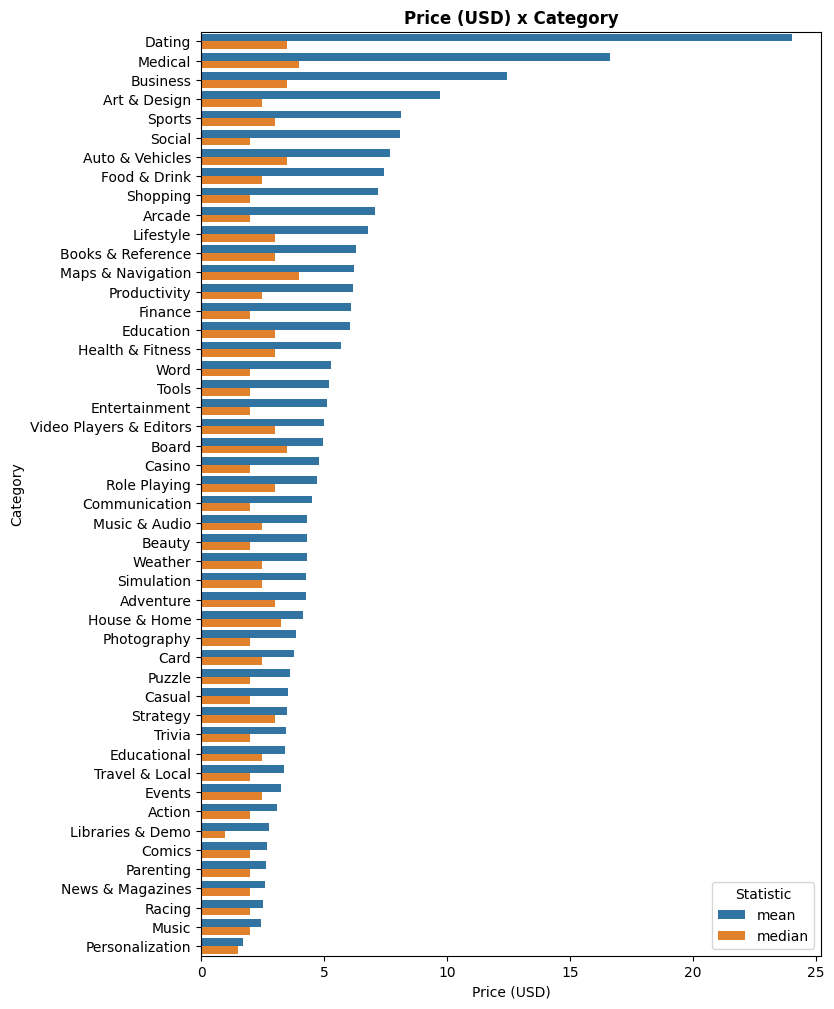

In [10]:
df2 = df[df["Price (USD)"] > 0].copy()
cat_price = df2.groupby(["Category"])["Price (USD)"].agg(["mean", "median"]).reset_index().sort_values("mean", ascending=False)
cat_long = cat_price.melt(id_vars="Category", value_vars=["mean", "median"], var_name="Metric", value_name="Price (USD)")

plt.figure(figsize=(8, 12))
sns.barplot(data=cat_long, x="Price (USD)", y="Category", hue="Metric")
plt.title("Price (USD) x Category", fontweight="bold")
plt.legend(title="Statistic")
plt.show()

A análise da variável `Price (USD)` em relação a `Category` mostra que, entre as categorias de aplicativos, as medianas de preço são semelhantes, enquanto as médias apresentam grande variação.  
As categorias `Dating`, `Medical` e `Business` ocupam as primeiras posições no ranking de preços médios da Play Store. Esse resultado sugere que essas áreas estão associadas a serviços especializados, funcionalidades profissionais ou modelos de monetização voltados para nichos específicos.

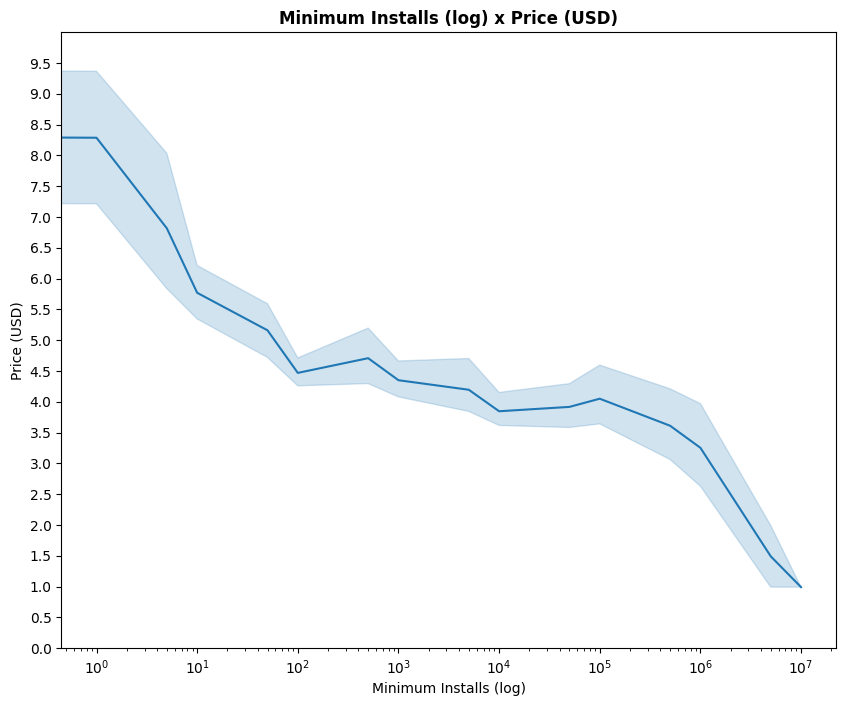

In [46]:
df2 = df[df["Price (USD)"] > 0].copy()
df2 = df2[["Price (USD)", "Minimum Installs"]]

plt.figure(figsize=(10, 8))
sns.lineplot(data=df2, x="Minimum Installs", y="Price (USD)")
plt.title("Minimum Installs (log) x Price (USD)", fontweight="bold")
plt.xscale("log")
plt.xlabel("Minimum Installs (log)")
plt.ylim(0, 10)
plt.yticks(np.arange(0, 10, .5))
plt.show()

A análise da variável `Minimum Installs` em escala logarítmica em relação a `Price (USD)` indica que existe uma relação negativa entre o preço e número de instalações. Esse resultado sugere que aplicativos com valor de venda elevado, são adquiridos com menor frequência na loja.

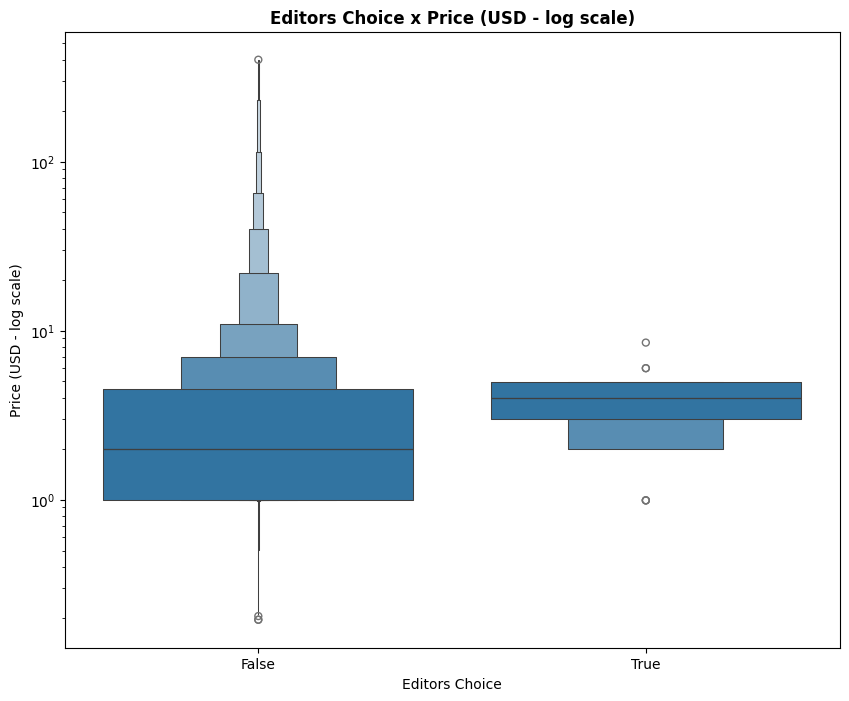

In [ ]:
# 'Price' = 'Editors Choice'
df2 = df.loc[df["Price (USD)"] > 0, ["Editors Choice", "Price (USD)"]].copy()

fig = plt.figure(figsize=(10, 8))
sns.boxenplot(data=df2, x="Editors Choice", y="Price (USD)")
plt.title("Editors Choice x Price (USD - log scale)", fontweight="bold")
plt.ylabel("Price (USD - log scale)")
plt.yscale("log")
plt.show()

A análise da variáveis `Editors Choice` em relação a `Price (USD)` em escala logarítmica mostra que, a mediana de aplicativos destacados como `Editors Choice`, é superior à dos aplicativos não destacados. Esse resultado indica que, em geral, os aplicativos selecionados pelos editores apresentam valores mais elevados na região central da distribuição.
Além disso, a dispersão dos 50% centrais (IQR) entre os aplicativos `Editors Choice` está mais concentrada em torno da mediana, sugerindo maior consistência de preços dentro desse grupo. Em contraste, os aplicativos não destacados apresentam maior variabilidade, com uma distribuição mais dispersa e presença de valores extremamente elevados, acima do limite superior IQR.

Total de valores 'Free' e 'Paid': [2195559, 42536]
Porcentagem de valores 'Free' e 'Paid': 1.9%


/tmp/ipykernel_478181/3921477477.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Porcentagem de valores 'Free' e 'Paid': {round((df2["Type"].value_counts()[1] * 100) / df2["Type"].value_counts()[0], 1)}%")
/tmp/ipykernel_478181/3921477477.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Porcentagem de valores 'Free' e 'Paid': {round((df2["Type"].value_counts()[1] * 100) / df2["Type"].value_counts()[0], 1)}%")


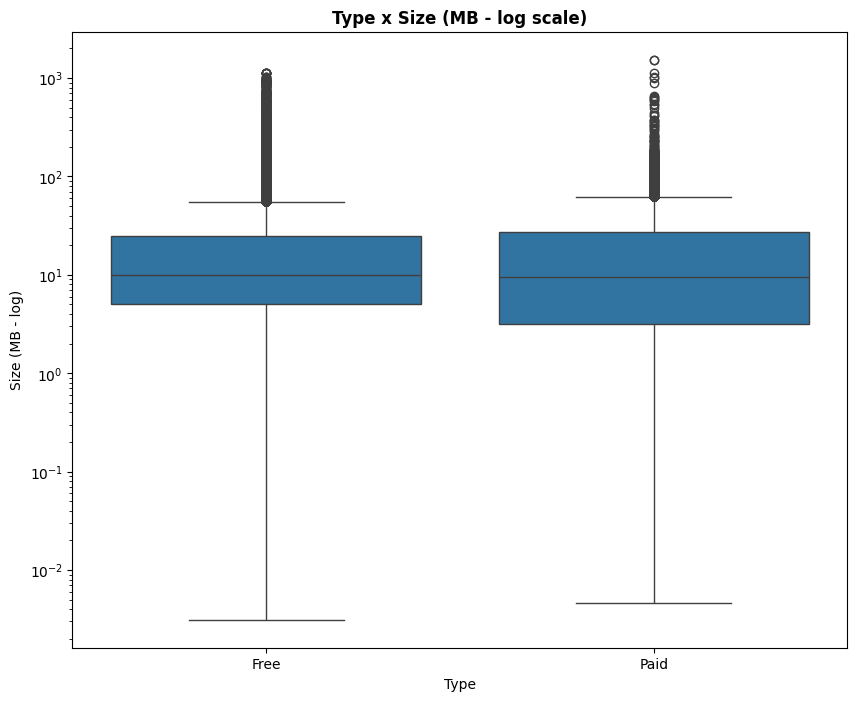

In [ ]:
df2 = df[["Price (USD)", "Size (MB)"]].copy()
df2["Type"] = df2["Price (USD)"].apply(lambda x: "Free" if x == 0 else "Paid")
print(f"Total de valores 'Free' e 'Paid': {df2["Type"].value_counts().tolist()}")
print(f"Porcentagem de valores 'Free' e 'Paid': {round((df2["Type"].value_counts()[1] * 100) / df2["Type"].value_counts()[0], 1)}%")
div(3)

plt.figure(figsize=(10, 8))
sns.boxplot(data=df2, x="Type", y="Size (MB)")
plt.title("Type x Size (MB - log scale)", fontweight="bold")
plt.yscale("log")
plt.ylabel("Size (MB - log)")
plt.show()

A análise da variável `Price (USD)` redistribuída nas categorias `Free` e `Paid` alocadas na coluna `Type` em relação a `Size (MB)` em escala logarítmica indica que, a mediana de tamanho entre aplicativos gratuitos e pagos é bastante semelhante. A dispersão dos 50% centrais (IQR) também apresenta valores próximos, embora a dispersão entre os aplicativos pagos seja ligeiramente maior.  
Esses resultados sugerem que não há diferença aparente de tamanho entre aplicativos das categorias `Free` e `Paid`. Vale considerar que, nesta base de dados, os aplicativos da categoria 'Paid' representam apenas 1,9% do total, o que pode limitar a robustez dessa comparação.

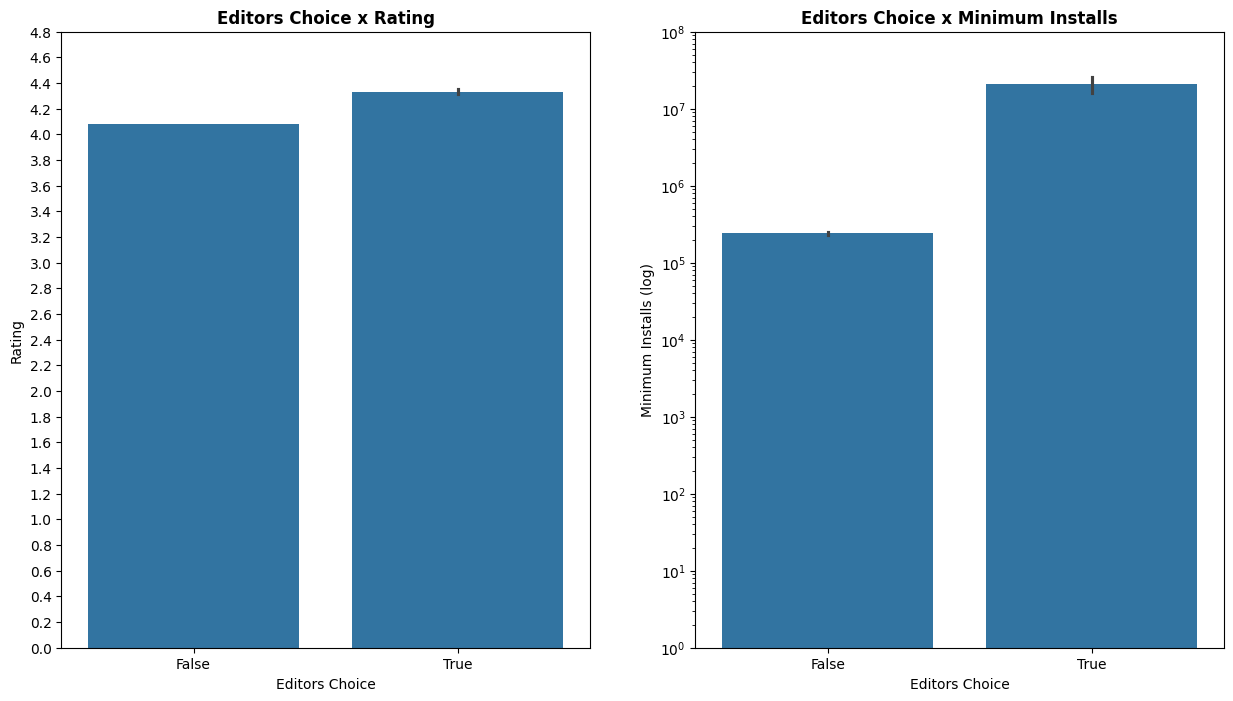

In [ ]:
df2 = df[["Rating", "Rating Count", "Minimum Installs", "Editors Choice"]].copy()
df2 = df2[df2["Rating Count"] >= 10]

fig, axs = plt.subplots(1, 2, figsize=(15, 8))
sns.barplot(data=df2, x="Editors Choice", y="Rating", ax=axs[0])
axs[0].set_title("Editors Choice x Rating", fontweight="bold")
axs[0].set(yticks=np.arange(0, 5, step=.2))

sns.barplot(data=df2, x="Editors Choice", y="Minimum Installs", ax=axs[1])
axs[1].set_title("Editors Choice x Minimum Installs", fontweight="bold")
axs[1].set(yscale="log", ylabel="Minimum Installs (log)", ylim=(10**0, 10**8))
plt.show()

A análise da variável `Editors Choice` em relação a `Rating`, indica que não há diferença aparente entre aplicativos padrão e destacados, embora estes apresentem uma pontuação ligeiramente melhor.  
Por outro lado, ao analisar a variável `Editors Choice` em relação a `Minimum Installs` na escala logarítmica, a diferença é notável. Aplicativos destacados como `Editors Choice` apresentam volume de instalações significativamente maior, sugerindo que esse método possa influenciar na escolha do usuário, demonstrando que essa é uma excelente estratégia de negócio.

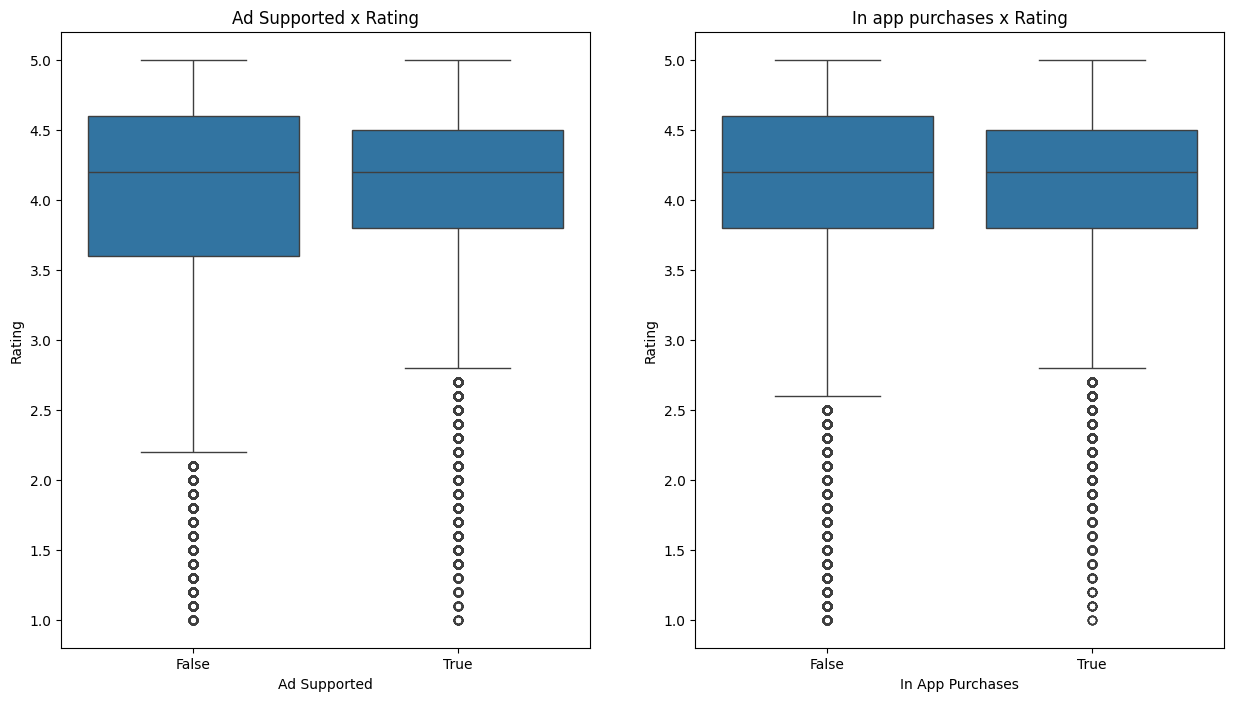

In [ ]:
df2 = df[["Rating", "Rating Count", "Ad Supported", "In App Purchases"]].copy()
df2 = df2[df2["Rating Count"] >= 10]

fig, axs = plt.subplots(1, 2, figsize=(15, 8))
sns.boxplot(data=df2, x="Ad Supported", y="Rating", ax=axs[0])
axs[0].set(title="Ad Supported x Rating")

sns.boxplot(data=df2, x="In App Purchases", y="Rating", ax=axs[1])
axs[1].set(title="In app purchases x Rating")

plt.show()

A análise da variável `Ad Supported ` em relação a `Rating` indica que, a mediana das avaliações é semelhante entre aplicativos com e sem anúncios. No entanto, aplicativos suportados por anúncios apresentam um intervalo interquartil (IQR) ligeiramente mais estreito, indicando maior consistência nas avaliações, enquanto aplicativos sem anúncios demonstram maior variabilidade.  
De maneira similar, a análise a variável `In App Purchases` em relação a `Rating` indica medianas praticamente iguais entre os grupos. Entretanto, aplicativos que não oferecem compras internas apresentam um intervalo interquartil (IQR) ligeiramente maior, indicando maior dispersão nas avaliações, enquanto aplicativos com compras internas demonstram avaliações um pouco mais consistentes. Vale considerar que nessa base dados, aplicativos indicados com In App Purchases `True` representam apenas 8,9% dos dados, o que pode limitar a robustez da comparação.

Text(0.5, 1.0, 'Minimum Android x Size (MB)')

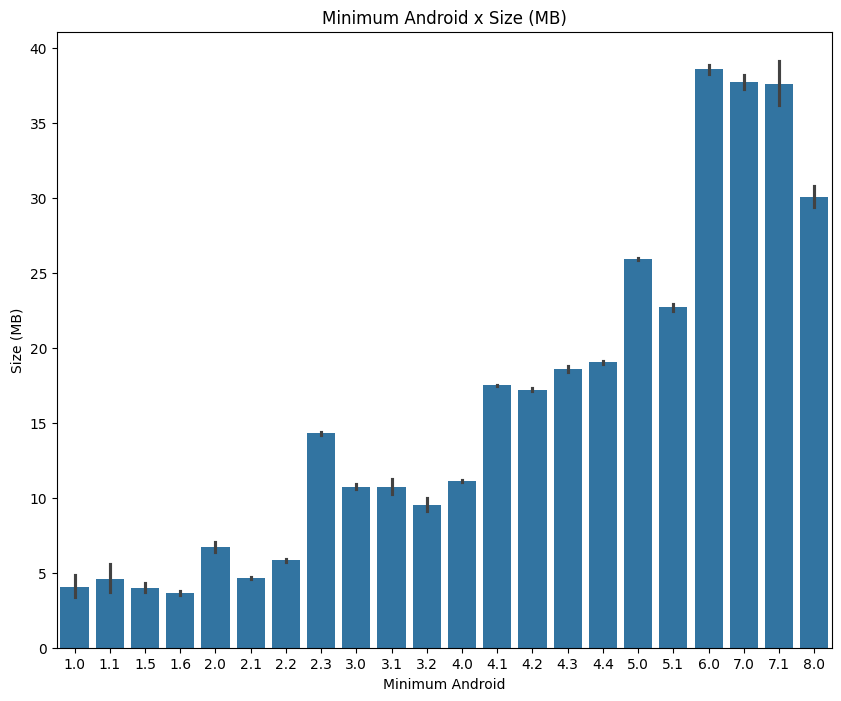

In [ ]:
df2 = df[["Minimum Android", "Size (MB)"]].copy()
df2["Minimum Android"] = df2["Minimum Android"].astype(str).str.extract(r"^(\d+\.\d+|\d+)")[0]
df2.dropna(subset=["Minimum Android"], inplace=True)
df2["Minimum Android"] = df2["Minimum Android"].astype(float)

plt.figure(figsize=(10, 8))
sns.barplot(data=df2, x="Minimum Android", y="Size (MB)")
plt.title("Minimum Android x Size (MB)")

A análise da variável `Minimum Android` em relação a `Size (MB)` indicam uma tendência de aumento no tamanho médio dos aplicativos conforme cresce a versão mínima exigida do sistema.  
Esse comportamento sugere que aplicativos desenvolvidos para versões mais recentes do Android tendem possuir mais funcionalidades, interfaces gráficas melhoradas, e bibliotecas adicionais, resultando em um maior consumo de armazenamento.  
Como consequência, usuários com dispositivos com sistemas defasados e capacidades de memória reduzidas, enfrentem limitações de compatibilidade de desempenho. Esses resultados reforçam a importância de estratégias de otimização e do desenvolvimento de aplicativos mais leves para ampliar a acessibilidade dos aplicativos.

## **Conclusão**  
  
Ao final da análise, foi possível obter resultados relevantes que contribuem para a compreensão do comportamento dos aplicativos na Google Play Store.  
Os resultados indicam que, embora a distribuição do preço entre as categorias se concentrem em valores próximos, existem valores extremos acima do intervalo interquartil, indicando a presença de aplicativos com preços significativamente mais elevados em nichos específicos. Por outro lado, não foi identificado relação relevante entre o preço e o tamanho do aplicativo, sugerindo que o preço não influência no tamanho dos aplicativos.  
Em relação a curadoria da plataforma, aplicativos classificados como Editors Choice apresentam preços mais elevados e menor dispersão, indicando uma precificação mais consistente. Além disso, a análise do número de instalação em função do preço mostra que, preços mais elevados estão associados a menores volumes de instalações.  
A relação entre Editors Choice e Rating não apresentou diferenças relevantes. Entretanto aplicativos destacados pela curadoria, demonstram um maior volume de instalações, indicando maior alcance e popularidade.  
A análise das variável Ad Supported e In App Purchases em relação a variável Rating mostrou que, não há diferenças significativas entre as medianas das avaliações de aplicativos com e sem esses recursos. Contudo, a distribuição dos 50% centrais é mais consistente quando esses mecanismos de monetização estão presentes.  
Por fim, a relação entre Minimum Android e Size indica uma tendência de aumento no tamanho dos aplicativos, à medida que versões mais recentes do sistema Android são exigidas, sugerindo maior demanda por recursos.